In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
from matplotlib import pyplot as plt

print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Matplotlib version: {mpl.__version__}")

Numpy version: 2.4.4
Pandas version: 3.0.2
Seaborn version: 0.13.2
Matplotlib version: 3.10.8


In [2]:
plt.rcParams.update(
    {
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "figure.dpi": 150,
    }
)

# Standard color palette used across all charts
PALETTE = ["#16a085", "#c0392b"]

In [3]:
file_ids = {
    "student_performance": "1hYmPJ8P2Zv6tyO1CAdpJkhnSIuJ3QHjX",
    "gym_membership": "17dJ3mXs9sCZ-0vzUE-tvSj0gtw-afaK1",
}

dataframes = {
    name: pd.read_csv(f"https://drive.google.com/uc?export=download&id={fid}")
    for name, fid in file_ids.items()
}

student_performance_data = dataframes["student_performance"]
gym_membership_data = dataframes["gym_membership"]

In [4]:
# Q1. Display the first 5 rows of the dataset, then print its shape
print(student_performance_data.shape)
student_performance_data.head()

(1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
# Q2. Print the average (mean) math score, reading score and writing score
print(student_performance_data[["math score", "reading score", "writing score"]].mean())

math score       66.089
reading score    69.169
writing score    68.054
dtype: float64


In [6]:
# Q3. Display all students who scored more than 90 in reading, and print how many
top_readers = student_performance_data[
    student_performance_data["reading score"] > 90
].reset_index(drop=True)
print("Number of students:", len(top_readers))
top_readers

Number of students: 62


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,master's degree,standard,none,90,95,93
1,female,group B,some college,standard,completed,88,95,92
2,female,group D,associate's degree,standard,none,85,91,89
3,female,group D,master's degree,standard,none,87,100,100
4,female,group E,bachelor's degree,standard,completed,99,100,100
...,...,...,...,...,...,...,...,...
57,female,group D,master's degree,standard,none,92,100,100
58,female,group E,associate's degree,standard,none,100,100,100
59,female,group D,bachelor's degree,standard,none,89,100,100
60,female,group C,associate's degree,standard,none,91,95,94


In [7]:
# Q4. Sort the dataset by math score in descending order and display the top 5 rows
top_math = (
    student_performance_data.sort_values("math score", ascending=False)
    .head()
    .reset_index(drop=True)
)
top_math

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group E,some college,standard,none,100,92,97
1,female,group E,bachelor's degree,standard,none,100,100,100
2,female,group E,associate's degree,standard,none,100,100,100
3,male,group E,associate's degree,free/reduced,completed,100,100,93
4,male,group A,some college,standard,completed,100,96,86


In [8]:
gym_membership_data.head()

,id,gender,birthday,Age,abonoment_type,visit_per_week,days_per_week,attend_group_lesson,fav_group_lesson,avg_time_check_in,avg_time_check_out,avg_time_in_gym,drink_abo,fav_drink,personal_training,name_personal_trainer,uses_sauna
0,1,Female,4/18/1997,27,Premium,4,"Mon, Sat, Tue, Wed",True,"Kickboxen, BodyPump, Zumba",19:31:00,21:27:00,116,False,NaN,False,NaN,True
1,2,Female,9/18/1977,47,Standard,3,"Mon, Sat, Wed",False,NaN,19:31:00,20:19:00,48,False,NaN,True,Chantal,False
2,3,Male,3/30/1983,41,Premium,1,Sat,True,XCore,8:29:00,10:32:00,123,True,"berry_boost, lemon",True,Mike,False
3,4,Male,4/12/1980,44,Premium,3,"Sat, Tue, Wed",False,NaN,9:54:00,11:33:00,99,True,passion_fruit,True,Mike,True
4,5,Male,9/10/1980,44,Standard,2,"Thu, Wed",True,"Running, Yoga, Zumba",8:29:00,9:19:00,50,False,NaN,True,Mike,False


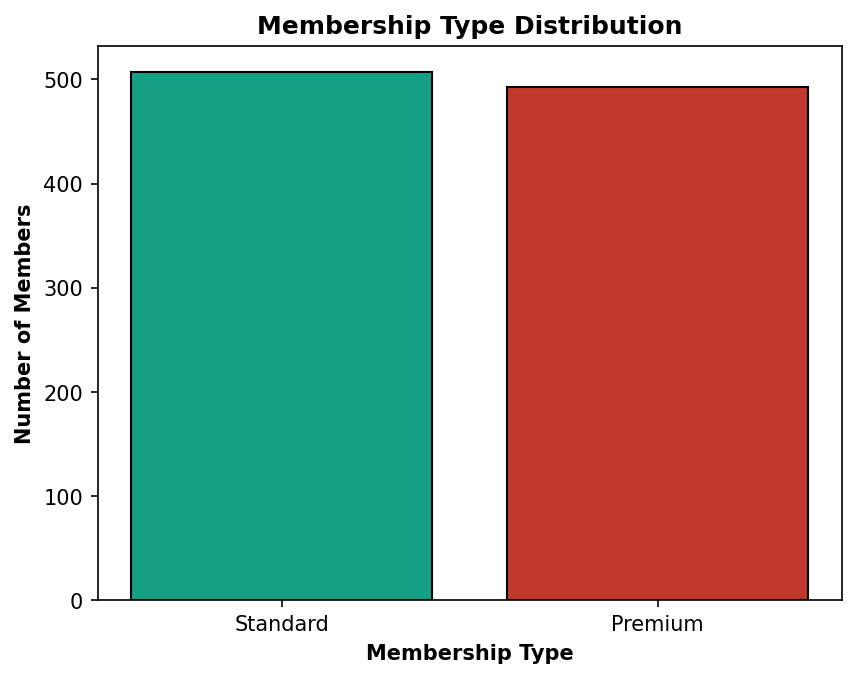

In [9]:
# Q5. Bar chart of membership types
counts = gym_membership_data["abonoment_type"].value_counts()

plt.bar(counts.index, counts.values, color=PALETTE, edgecolor="black")
plt.title("Membership Type Distribution")
plt.xlabel("Membership Type")
plt.ylabel("Number of Members")
plt.show()

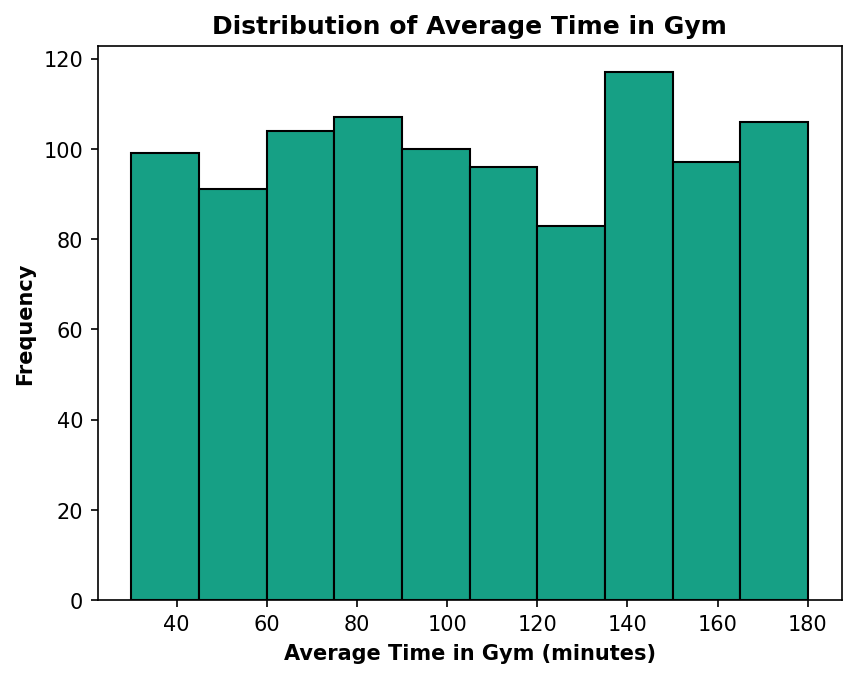

In [10]:
# Q6. Histogram of avg_time_in_gym
plt.hist(
    gym_membership_data["avg_time_in_gym"], bins=10, color=PALETTE[0], edgecolor="black"
)
plt.title("Distribution of Average Time in Gym")
plt.xlabel("Average Time in Gym (minutes)")
plt.ylabel("Frequency")
plt.show()

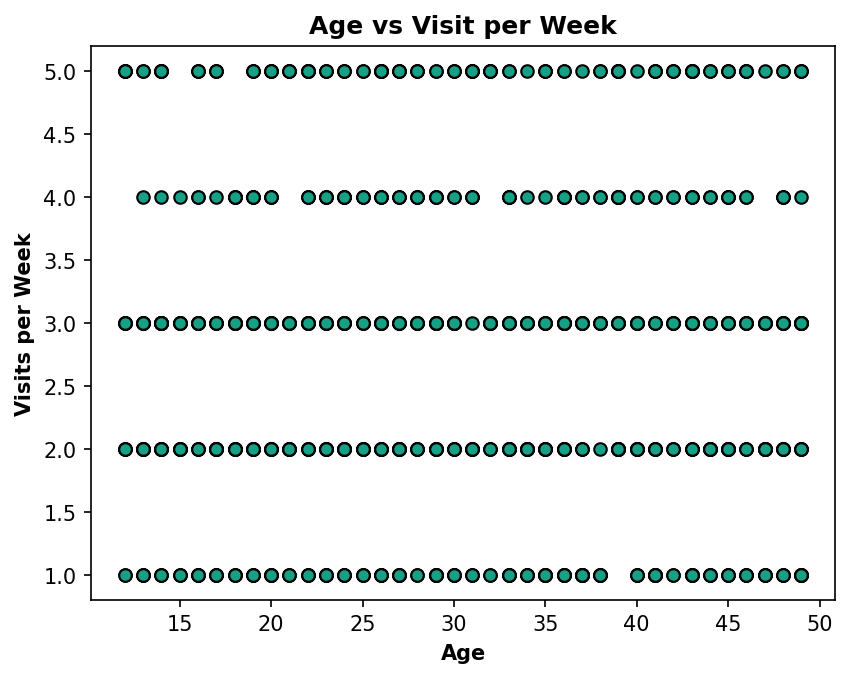

In [11]:
# Q7. Scatter plot of Age vs visit_per_week
plt.scatter(
    gym_membership_data["Age"],
    gym_membership_data["visit_per_week"],
    color=PALETTE[0],
    edgecolor="black",
)
plt.title("Age vs Visit per Week")
plt.xlabel("Age")
plt.ylabel("Visits per Week")
plt.show()

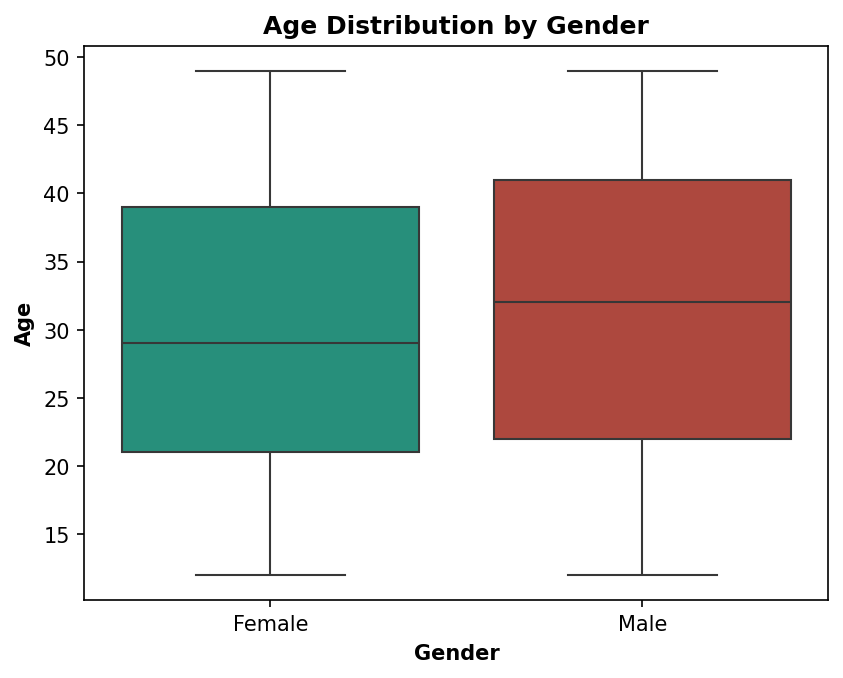

In [12]:
# Q8. Box plot - gender vs Age
sns.boxplot(
    x="gender",
    y="Age",
    data=gym_membership_data,
    hue="gender",
    palette=PALETTE,
    legend=False,
)
plt.title("Age Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.show()

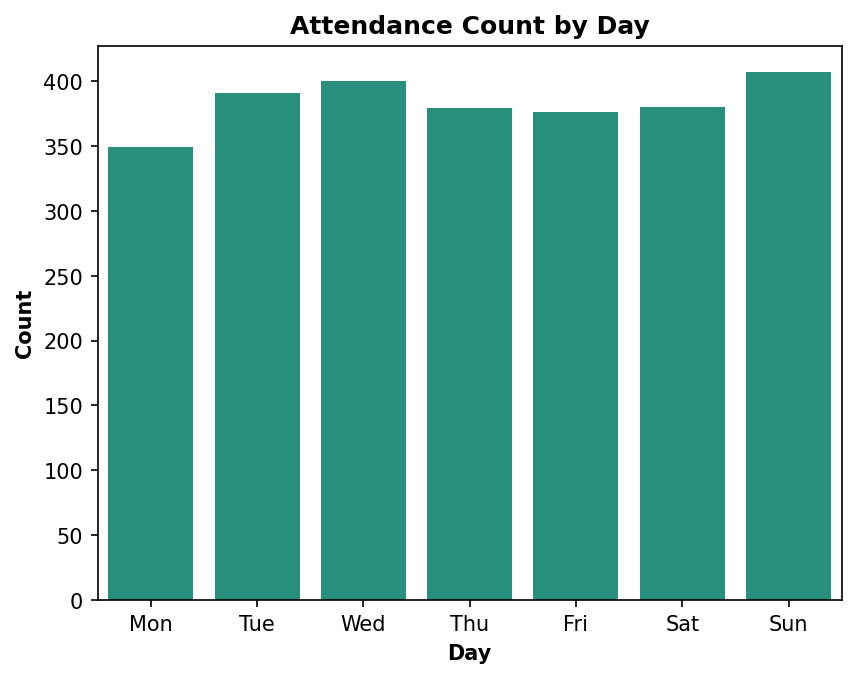

In [13]:
# Q9. Count plot - days_per_week
days_split = gym_membership_data["days_per_week"].str.split(", ").explode()

sns.countplot(
    x=days_split,
    color=PALETTE[0],
    order=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
)
plt.title("Attendance Count by Day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.show()

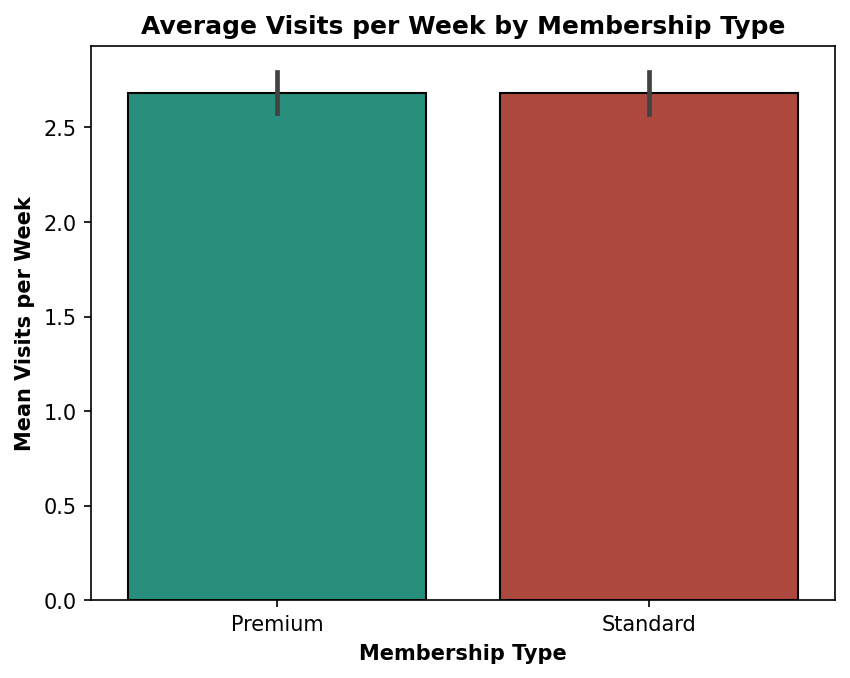

In [14]:
# Q10. Bar plot - mean visit_per_week per abonoment_type
sns.barplot(
    x="abonoment_type",
    y="visit_per_week",
    data=gym_membership_data,
    hue="abonoment_type",
    palette=PALETTE,
    legend=False,
    edgecolor="black",
)
plt.title("Average Visits per Week by Membership Type")
plt.xlabel("Membership Type")
plt.ylabel("Mean Visits per Week")
plt.show()